# HAH913E – Physical Activity Assignment

**GitHub repository:** https://github.com/sarah-mussotte/Physical-activity-00-Project

**Team members:**
- Faraj Tania
- Mussotte Sarah
- Vigneau-Sugar Thomas


## 1. Loading the accelerometer data

The dataset contains accelerometer measurements along the x, y, and z axes, expressed in g. The time variable `t` is expressed in seconds.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
data = np.loadtxt("0_z.csv", delimiter=",", skiprows=2)

t = data[:, 0]
x = data[:, 1]
y = data[:, 2]
z = data[:, 3]

print(data.shape)
print(data[:5])

(21000, 4)
[[ 0.     -0.0938 -0.0156  0.9531]
 [ 0.02   -0.0938 -0.0156  0.9531]
 [ 0.04   -0.0938 -0.0156  0.9531]
 [ 0.06   -0.0938 -0.0156  0.9531]
 [ 0.08   -0.0938 -0.0156  0.9531]]


## 2. Computing ENMO

ENMO (Euclidean Norm Minus One) combines the acceleration measured along the three axes into a single value.

First, the vector magnitude of the acceleration is calculated as:

$$
VM = \sqrt{x^2 + y^2 + z^2}
$$

The gravitational component of 1 g is then subtracted:

$$
ENMO = \sqrt{x^2 + y^2 + z^2} - 1
$$

For this assignment, the resulting ENMO values are kept without truncating negative values, in order to reproduce the provided reference plots.

In [14]:
def calculate_enmo(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2) - 1

enmo = calculate_enmo(x, y, z)

In [15]:
print(enmo[:5])
print("Minimum ENMO:", enmo.min())
print("Maximum ENMO:", enmo.max())

[-0.04216838 -0.04216838 -0.04216838 -0.04216838 -0.04216838]
Minimum ENMO: -0.8894933486164747
Maximum ENMO: 12.784615518758585


## 3. ENMO integration over 30-second epochs

For my contribution to the group assignment, the ENMO signal is divided into fixed-length epochs of 30 seconds.

For each epoch, the ENMO values are summed and scaled by the epoch duration expressed in minutes:

$$
I_T =
\left(
\sum_{i=1}^{N} ENMO_i
\right)
\frac{T}{60}
$$

where:

- $I_T$ is the integrated ENMO for an epoch,
- $T$ is the epoch length in seconds,
- $N$ is the number of samples in that epoch.

For my contribution:

$$
T = 30\text{ s}
$$

In [17]:
fs = 1 / (t[1] - t[0])

print("Sampling frequency:", fs, "Hz")

Sampling frequency: 50.0 Hz


In [ ]:
def integrate_enmo(enmo, epoch_seconds, fs):
    samples_per_epoch = int(epoch_seconds * fs)
    n_epochs = len(enmo) // samples_per_epoch

    integrated = []

    for i in range(n_epochs):
        start = i * samples_per_epoch
        end = start + samples_per_epoch
        epoch = enmo[start:end]

        value = np.sum(epoch) * (epoch_seconds / 60)
        integrated.append(value)

    return np.array(integrated)

## 4. Visualization using 30-second epochs

The integrated ENMO is represented using 30-second epochs. The original ENMO signal is shown below to compare the accumulated activity with the signal over time.

In [ ]:
def plot_enmo_epoch(t, enmo, epoch_seconds, fs):
    integrated = integrate_enmo(enmo, epoch_seconds, fs)

    epoch_times = np.arange(len(integrated)) * epoch_seconds / 60
    epoch_width = epoch_seconds / 60

    plt.figure(figsize=(10, 6))

    plt.subplot(2, 1, 1)
    plt.bar(epoch_times, integrated, width=epoch_width * 0.9, align="edge")
    plt.ylabel("Integrated ENMO (g.min)")
    plt.title(f"ENMO integrated over {epoch_seconds:.1f} s intervals")

    plt.subplot(2, 1, 2)
    plt.plot(t / 60, enmo)
    plt.xlabel("Time (minutes)")
    plt.ylabel("ENMO (g)")
    plt.title("ENMO over Time")

    plt.tight_layout()
    plt.show()

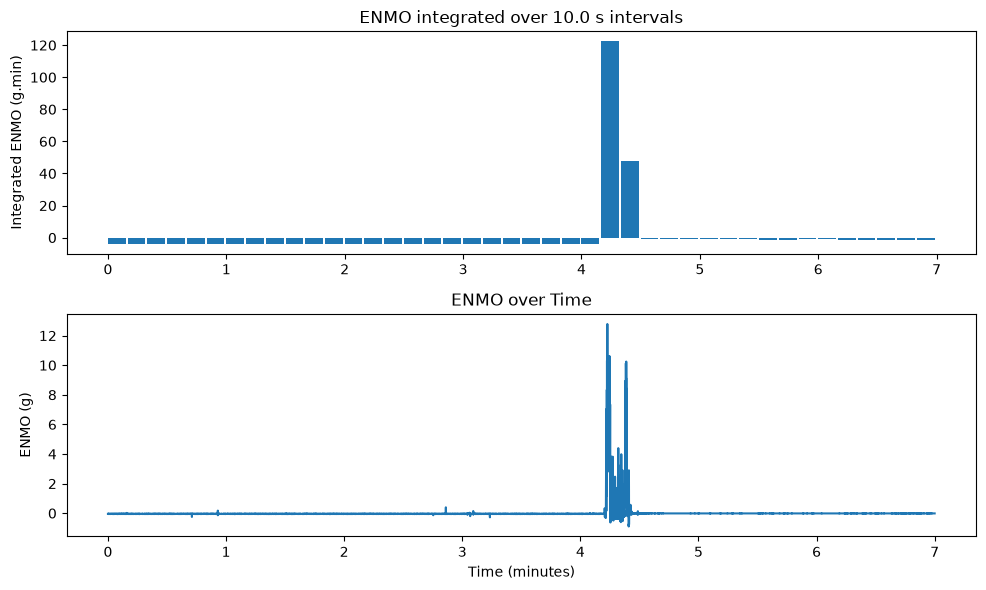

In [ ]:
plot_enmo_epoch(t, enmo, 30, fs)

## 5. AI assistance (Vigneau-Sugar Thomas)

AI assistance was used to clarify the main methodological steps of the analysis. The generated suggestions were reviewed before being included in the notebook.

### Prompt 1
"What is the formula for ENMO using tri-axial accelerometer data x, y, and z?"

**Review and modification:**  
The suggested ENMO formula was checked and retained for the calculation used in this notebook.

### Prompt 2
"What does it mean to integrate ENMO over an epoch?"

**Review and modification:**  
The proposed approach was compared with the reference plots provided in the assignment and adapted for the 30-second epoch used in my contribution.

### Prompt 3
"Should negative ENMO values be set to zero?"

**Review and modification:**  
Truncating negative ENMO values to zero was considered and tested. This option was not retained because it did not reproduce the reference plot provided in the assignment.